# 基于 CNN 的 SVHN 图像分类实验报告

## 1 实验目的
本实验以 SVHN（Street View House Numbers）数据集中的 Format 2 为研究对象，完成街景门牌数字的 10 分类任务。通过本次实验，掌握基于 PyTorch 的图像分类基本流程，包括数据读取、数据预处理、模型构建、训练与测试流程。。

## 2 数据集与预处理
### 2.1 数据集介绍
SVHN 是来源于真实街景图像的门牌数字数据集。本实验使用的是 SVHN Format 2，其特点是每张图像只对应一个中心数字标签，任务属于单标签 10 分类问题。图像尺寸为 32×32×3，为 RGB 彩色图像，类别为数字 0–9。训练集共 73257 张，测试集共 26032 张。

### 2.2 据预处理方法
实验中对训练集和测试集采用了不同的数据预处理策略。训练集引入随机裁剪、轻微旋转和颜色扰动，主要是为了增强模型对位置偏移、光照变化和小幅形变的鲁棒性，提高泛化能力；测试集仅进行张量化和标准化，以保证测试过程稳定、公平。标准化，以保证测试过程稳定、公平。

In [ ]:
# 训练集做增强与标准化
class SVHNDataset(Dataset):
    def __init__(self, mat_path, transform=None):
        super().__init__()
        data = sio.loadmat(mat_path)

        self.images = data["X"]
        self.labels = data["y"].squeeze()

        # 将错误的标签改正
        self.labels[self.labels == 10] = 0
        # 转成 (N, 32, 32, 3)
        self.images = np.transpose(self.images, (3, 0, 1, 2))
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.images[idx]
        label = int(self.labels[idx])
        if self.transform is not None:
            img = self.transform(img)
        else:
            img = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1) / 255.0

        return img, label

# 数据预处理
def get_transforms():
    train_transform = transforms.Compose([
        # numpy 转换为 PIL，方便后续图像增强
        transforms.ToPILImage(),
        # 随机裁剪，增强鲁棒性
        transforms.RandomCrop(32, padding=4),
        # 轻微旋转
        transforms.RandomRotation(10),
        transforms.ColorJitter(
            brightness=0.2,
            contrast=0.2,
            saturation=0.2
        ),
        transforms.ToTensor(),
        # 归一化到 [0,1]
        transforms.Normalize(
            mean=[0.4377, 0.4438, 0.4728],
            std=[0.1980, 0.2010, 0.1970]
        )
    ])

    test_transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.4377, 0.4438, 0.4728],
            std=[0.1980, 0.2010, 0.1970]
        )
    ])

    return train_transform, test_transform

## 3 网络结构

本次实验中使用三两种网络结构，除了基础的 CNN 之外，尝试了 ResNet18和 WideResNet 两种 网络结构尝试进一步改进分类效果。

### 3.1 Baseline CNN结构

首先尝试使用最基础的 CNN 网络结构，使用的卷积神经网络由特征提取模块和分类模块两部分组成。网络包含 6 个卷积层，卷积核大小均为 3×3，每两个卷积层后接一个 2×2 最大池化层，逐步将特征图尺寸由 32×32 压缩到 16×16、8×8 和 4×4。最终输出张量大小为 128×4×4，展平后得到 2048 维特征，再通过一个 256 维全连接层和最终的 10 类输出层完成分类。每个卷积层后使用 ReLU 激活函数，具体构成为：

- 两层 32 通道的卷积层 Conv1 和Conv2 + 最大池化层
- 两层 64 通道的卷积层 Conv3 和Conv4 + 最大池化层
- 两层 128 通道的卷积层 Conv5 和Conv6 + 最大池化层
- 展平
- 全连接层
- 输出层

此外，网络中加入了 Dropout，在卷积块后使用 Dropout(0.25)，全连接层后使用 Dropout(0.5)，主要作用是抑制过拟合，提高模型泛化能力。，提高模型泛化能力。

In [ ]:
# CNN 网络构建，features：卷积特征提取部分 classifier：全连接分类部分
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            # block 1 提取低层特征
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            # 对通道做归一化
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(kernel_size=2, stride=2),   # 32x32 -> 16x16
            nn.Dropout(0.25),

            # block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(kernel_size=2, stride=2),   # 16x16 -> 8x8
            nn.Dropout(0.25),

            # block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(kernel_size=2, stride=2),   # 8x8 -> 4x4
            nn.Dropout(0.25)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

### 3.2 ResNet18 结构

ResNet 的核心思想是引入残差连接，通过学习残差映射来缓解深层网络训练中的梯度退化问题，使更深的网络更容易优化。考虑到 SVHN 图像尺寸仅为 32×32，本实验未直接使用 ImageNet 标准版 ResNet18，而是进行了小图像适配。具体而言，将首层卷积由标准的 7×7、stride=2 修改为 3×3、stride=1，并移除了初始最大池化层，这样可以减少小尺寸图像在浅层阶段的信息损失，减少丢失图像中的局部边缘和笔画结构特征。

修改后的 ResNet18 由一个初始卷积层和四个残差阶段组成。初始卷积层将输入的 3 通道图像映射为 64 通道特征图，输出尺寸保持为 32×32。随后，网络依次经过四个残差阶段 layer1 到 layer4。每个阶段均由 2 个 BasicBlock 构成，而每个 BasicBlock 包含 2 个 3×3 卷积层，因此四个阶段总共包含 16 个卷积层；再加上首层卷积和末端全连接层，整个网络共 18 层，即 ResNet18。在尺寸变化方面，layer1 保持特征图大小不变，输出为 64×32×32；layer2 将通道数提升至 128，并将特征图下采样为 16×16；layer3 输出为 256×8×8；layer4 输出为 512×4×4。之后通过全局平均池化将每个通道的空间特征压缩为单一响应值，得到 512 维特征向量，并通过全连接层映射到 10 个类别输出。输出。

In [ ]:
# ResNet18 网络结构
def build_resnet18(num_classes=10):

    model = models.resnet18(weights=None)

    model.conv1 = nn.Conv2d(
        in_channels=3,
        out_channels=64,
        kernel_size=3,
        stride=1,
        padding=1,
        bias=False
    )
    model.maxpool = nn.Identity()

    # 最后一层改成 10 分类
    model.fc = nn.Linear(model.fc.in_features, num_classes)

    return model

### 3.3 WideResNet 结构
WideResNet 的基本思想是通过增加输出通道数，让模型能够捕获更丰富的特征信息，从而提高分类准确率。残差网络如果一味加深，会出现两个问题：性能提升并不总是和层数成正比；
非常深的残差网络在特征复用上会出现收益递减，收敛速度也未必理想。因此，WideResNet 通过减少网络深度的极端增长，转而增加每一层的通道数，也就是让网络“更宽”，从而有利于提取丰富特征。

在本次实验中采用深度为 28、宽度系数为 2 的宽残差网络。WideResNet 的整体结构由一个初始卷积层、三个宽残差阶段以及一个全局平均池化和全连接分类层组成。输入为 32×32×3 的 RGB 图像，首先经过一个 3×3 卷积层映射到 16 通道特征图；随后依次通过三个宽残差阶段，输出通道数分别为 32、64 和 128，其中第二和第三阶段进行下采样，使特征图尺寸由 32×32 逐步减小为 16×16 和 8×8。最后，经过 Batch Normalization、ReLU、全局平均池化和全连接层，输出 10 个类别分数以完成数字分类任务。### 3.2 ResNet18 结构

ResNet 的核心思想是引入残差连接，通过学习残差映射来缓解深层网络训练中的梯度退化问题，使更深的网络更容易优化。考虑到 SVHN 图像尺寸仅为 32×32，本实验未直接使用 ImageNet 标准版 ResNet18，而是进行了小图像适配。具体而言，将首层卷积由标准的 7×7、stride=2 修改为 3×3、stride=1，并移除了初始最大池化层，这样可以减少小尺寸图像在浅层阶段的信息损失，减少丢失图像中的局部边缘和笔画结构特征。

修改后的 ResNet18 由一个初始卷积层和四个残差阶段组成。初始卷积层将输入的 3 通道图像映射为 64 通道特征图，输出尺寸保持为 32×32。随后，网络依次经过四个残差阶段 layer1 到 layer4。每个阶段均由 2 个 BasicBlock 构成，而每个 BasicBlock 包含 2 个 3×3 卷积层，因此四个阶段总共包含 16 个卷积层；再加上首层卷积和末端全连接层，整个网络共 18 层，即 ResNet18。在尺寸变化方面，layer1 保持特征图大小不变，输出为 64×32×32；layer2 将通道数提升至 128，并将特征图下采样为 16×16；layer3 输出为 256×8×8；layer4 输出为 512×4×4。之后通过全局平均池化将每个通道的空间特征压缩为单一响应值，得到 512 维特征向量，并通过全连接层映射到 1

In [ ]:
class WideBasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, dropout_rate, stride):
        super().__init__()

        self.bn1 = nn.BatchNorm2d(in_channels)
        self.relu1 = nn.ReLU(inplace=True)
        self.conv1 = nn.Conv2d(
            in_channels, out_channels,
            kernel_size=3, stride=stride, padding=1, bias=False
        )

        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu2 = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(p=dropout_rate)
        self.conv2 = nn.Conv2d(
            out_channels, out_channels,
            kernel_size=3, stride=1, padding=1, bias=False
        )

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Conv2d(
                in_channels, out_channels,
                kernel_size=1, stride=stride, bias=False
            )

    def forward(self, x):
        out = self.conv1(self.relu1(self.bn1(x)))
        out = self.conv2(self.dropout(self.relu2(self.bn2(out))))
        out += self.shortcut(x)
        return out


class WideResNet(nn.Module):

    def __init__(self, depth=28, widen_factor=2, dropout_rate=0.3, num_classes=10):
        super().__init__()

        assert (depth - 4) % 6 == 0, "WideResNet depth should satisfy depth = 6n + 4"
        n = (depth - 4) // 6
        k = widen_factor

        n_channels = [16, 16 * k, 32 * k, 64 * k]

        self.conv1 = nn.Conv2d(3, n_channels[0], kernel_size=3, stride=1, padding=1, bias=False)

        self.layer1 = self._make_layer(
            in_channels=n_channels[0],
            out_channels=n_channels[1],
            num_blocks=n,
            dropout_rate=dropout_rate,
            stride=1
        )
        self.layer2 = self._make_layer(
            in_channels=n_channels[1],
            out_channels=n_channels[2],
            num_blocks=n,
            dropout_rate=dropout_rate,
            stride=2
        )
        self.layer3 = self._make_layer(
            in_channels=n_channels[2],
            out_channels=n_channels[3],
            num_blocks=n,
            dropout_rate=dropout_rate,
            stride=2
        )

        self.bn = nn.BatchNorm2d(n_channels[3])
        self.relu = nn.ReLU(inplace=True)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(n_channels[3], num_classes)

        self._initialize_weights()

    def _make_layer(self, in_channels, out_channels, num_blocks, dropout_rate, stride):
        layers = []
        for i in range(num_blocks):
            block_stride = stride if i == 0 else 1
            block_in_channels = in_channels if i == 0 else out_channels
            layers.append(
                WideBasicBlock(
                    in_channels=block_in_channels,
                    out_channels=out_channels,
                    dropout_rate=dropout_rate,
                    stride=block_stride
                )
            )
        return nn.Sequential(*layers)

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1.0)
                nn.init.constant_(m.bias, 0.0)
            elif isinstance(m, nn.Linear):
                nn.init.constant_(m.bias, 0.0)

    def forward(self, x):
        out = self.conv1(x)         
        out = self.layer1(out)      
        out = self.layer2(out)      
        out = self.layer3(out)      
        out = self.relu(self.bn(out))
        out = self.avgpool(out)     
        out = torch.flatten(out, 1)
        out = self.fc(out)
        return out

def build_wideresnet(num_classes=10):
    return WideResNet(depth=28, widen_factor=2, dropout_rate=0.3, num_classes=num_classes)


## 4 实验结果分析

本实验中，Baseline CNN 与 ResNet18 均在相同任务上训练，共训练 50 个 epoch。训练过程中记录以下指标：
- Train Accuracy
- Test Accuracy
- Train Loss
- Test Loss
优化采用 Adam。通过绘制训练集与测试集的准确率曲线和损失曲线，可以较为直观地分析模型的收敛速度、拟合能力和泛化性能。和泛化性能。

In [ ]:
# 训练 / 测试函数
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    running_correct = 0
    total = 0
    # 前向传播/计算损失/反向传播/更新参数
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total

    return epoch_loss, epoch_acc


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    running_correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total

    return epoch_loss, epoch_acc

### 4.1 结果图像
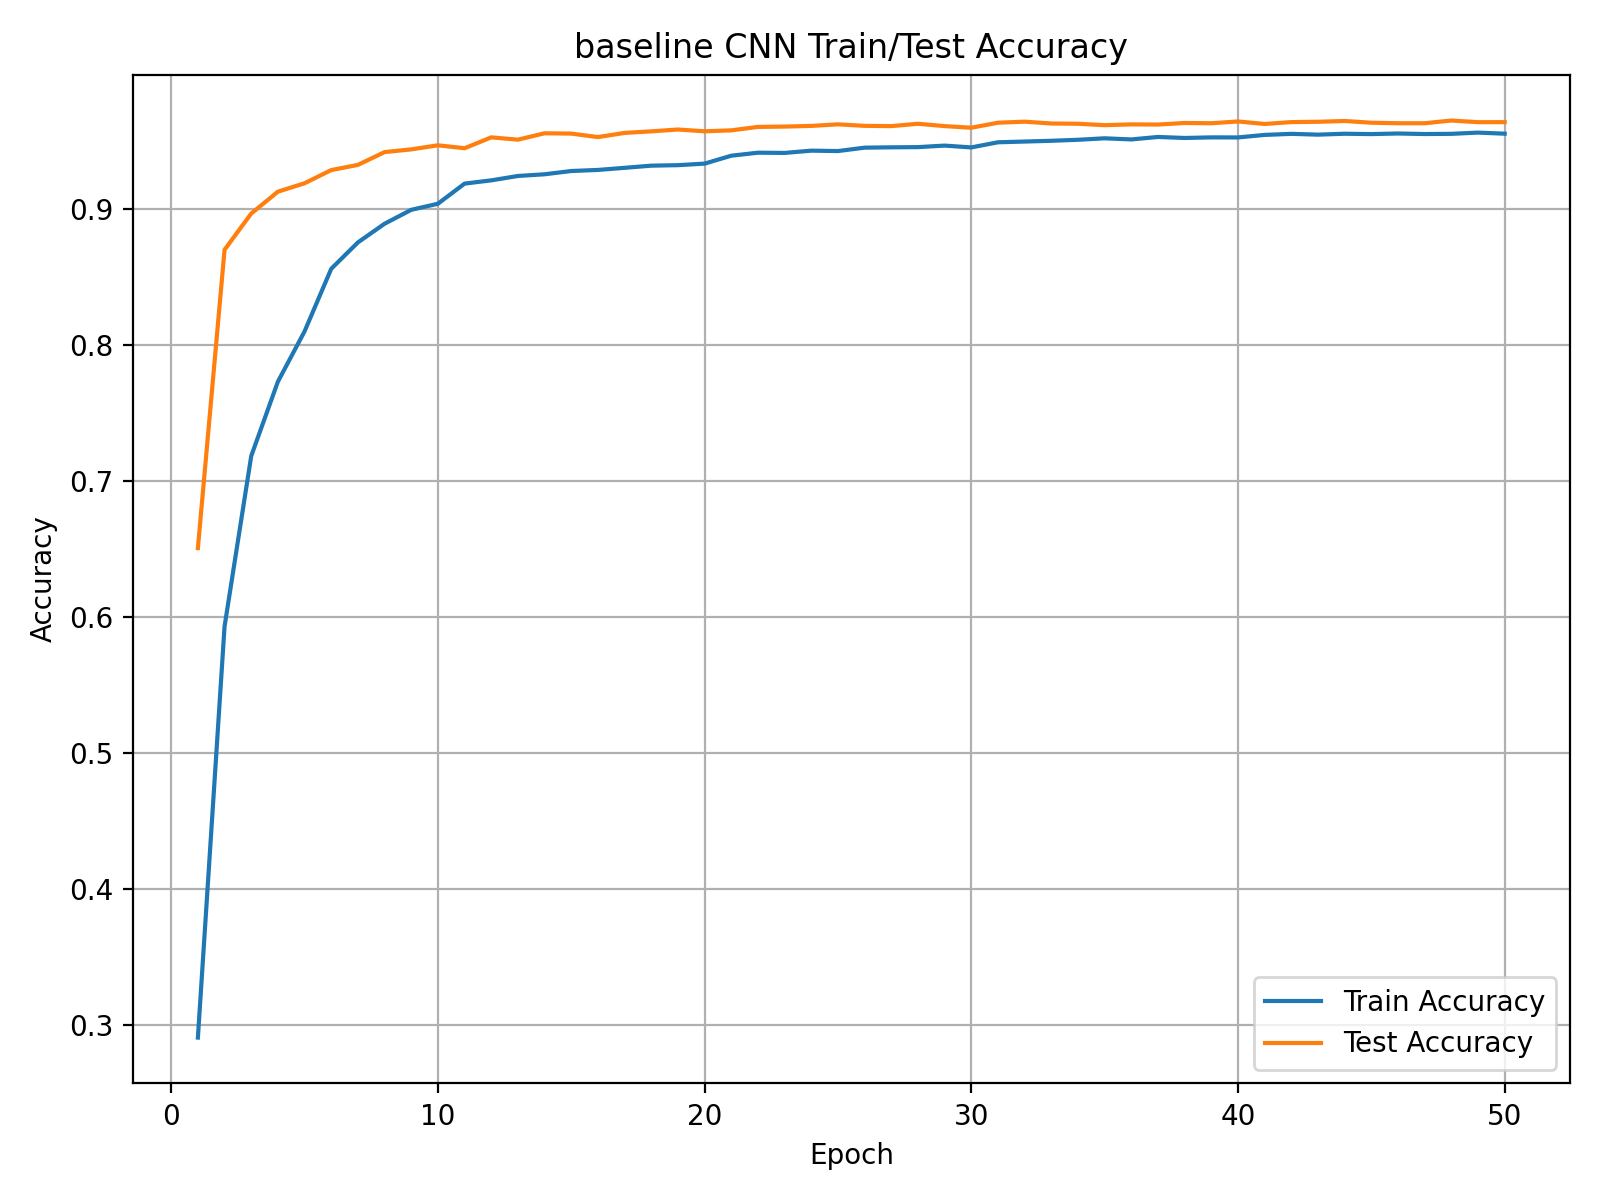
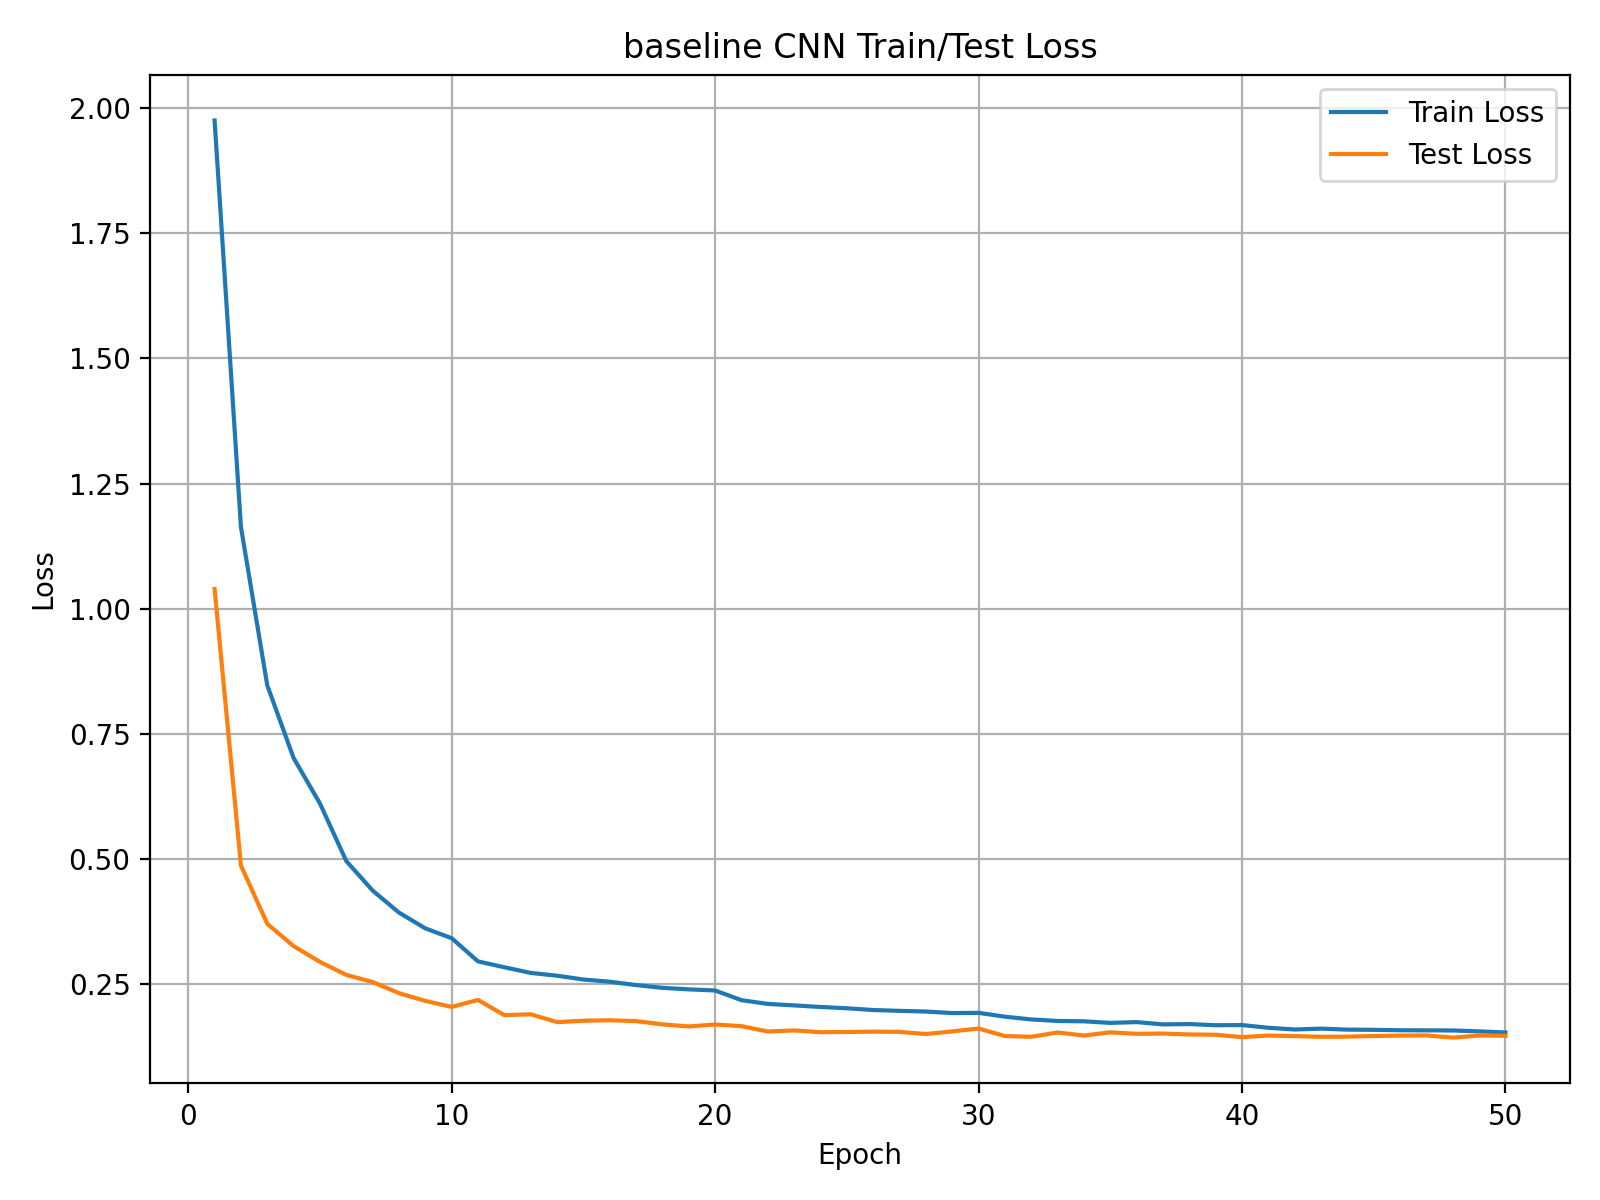
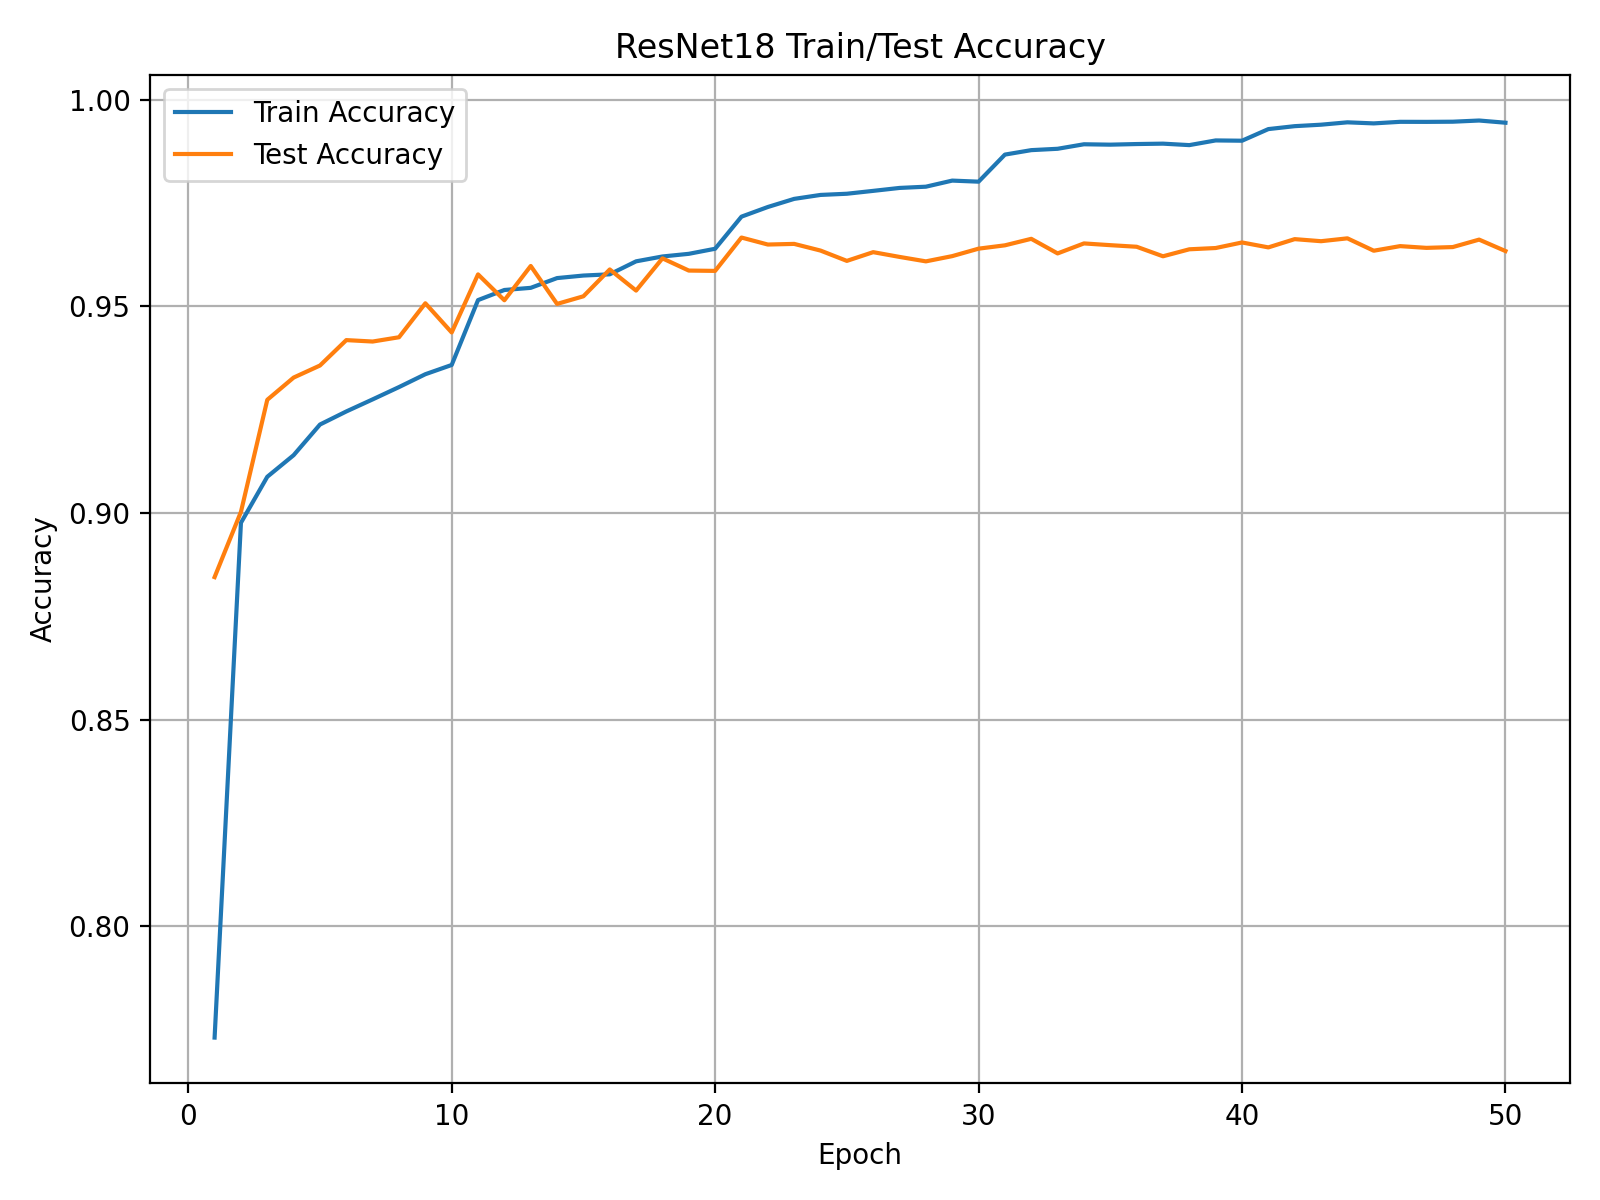
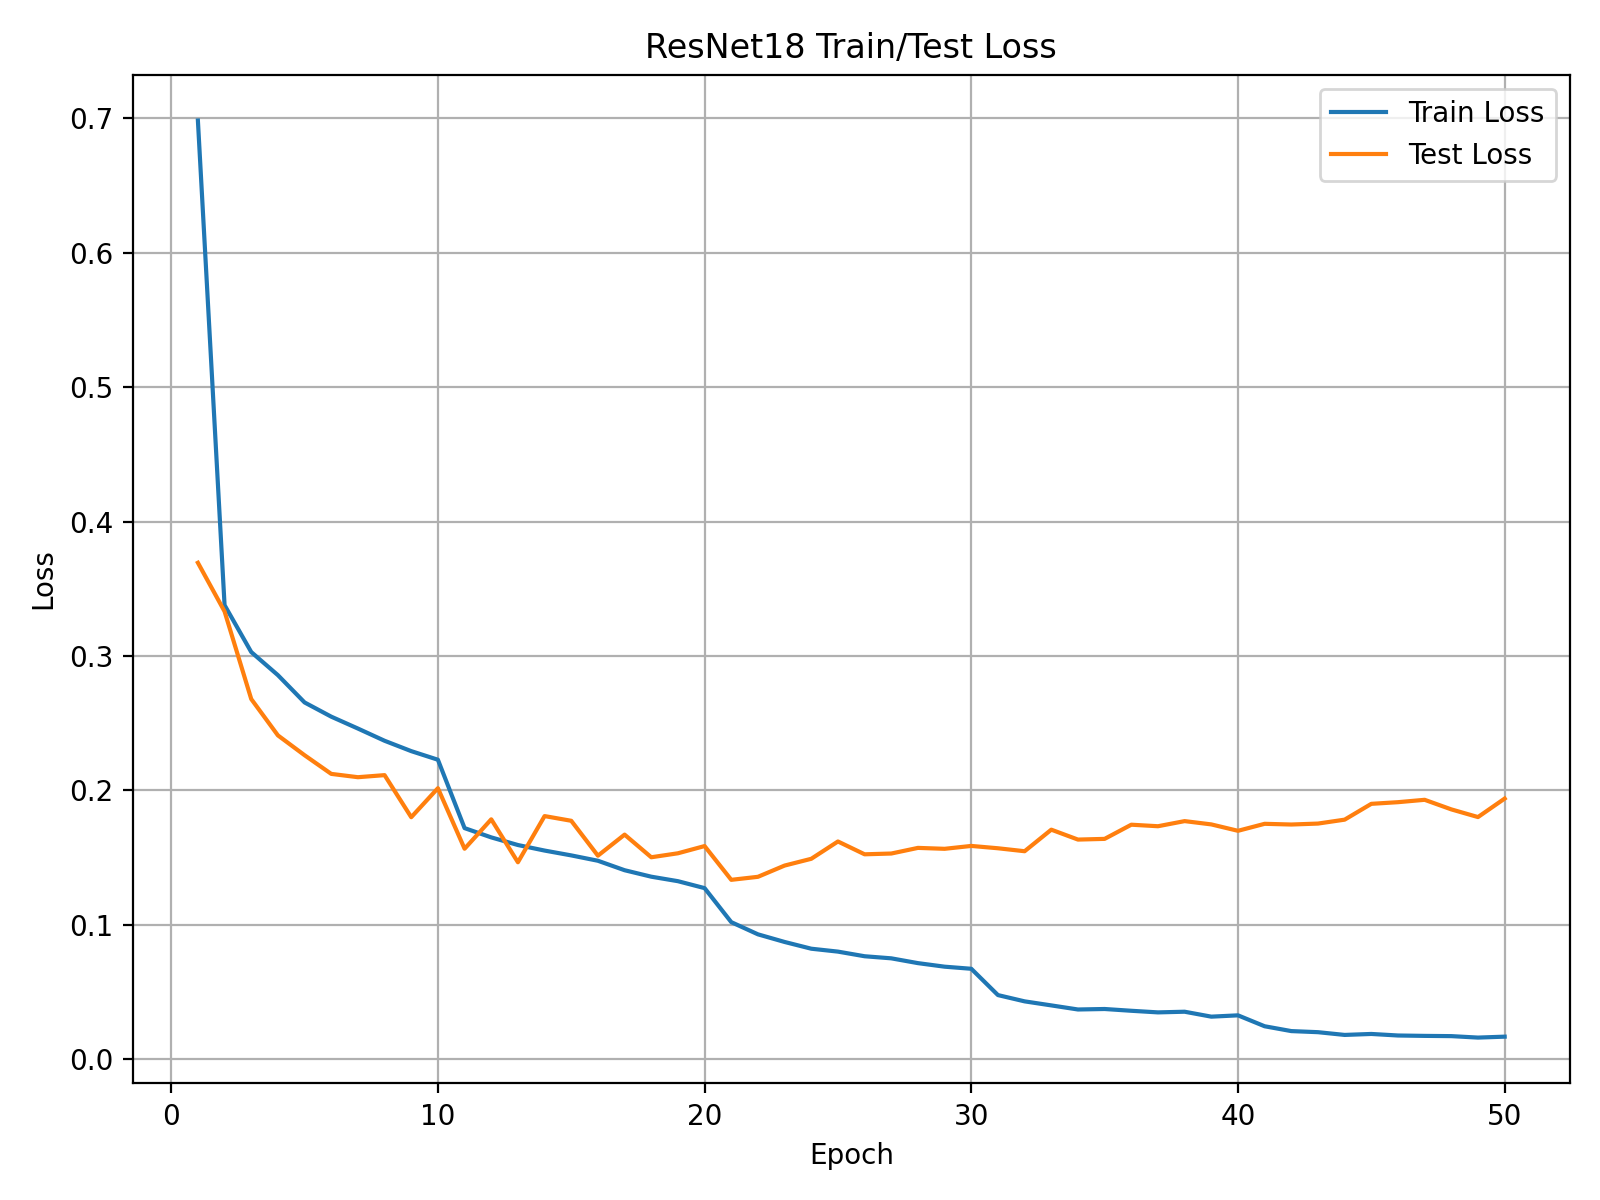
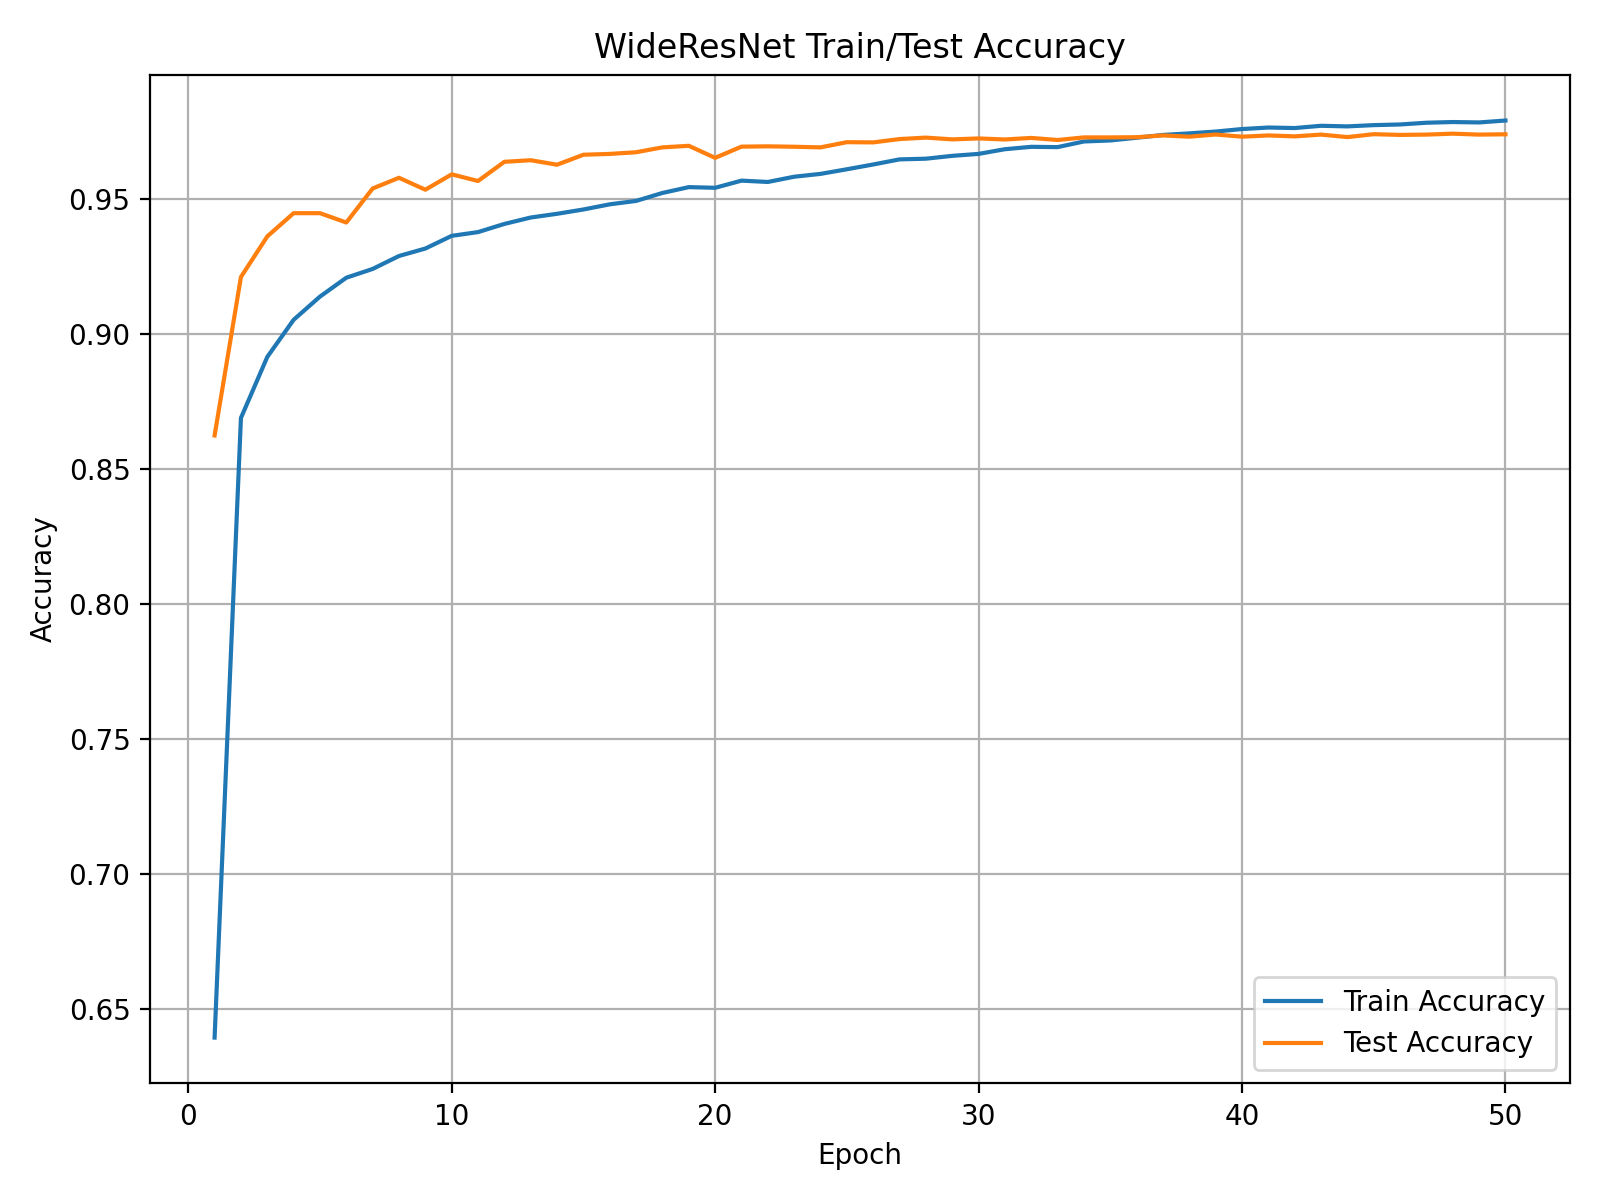
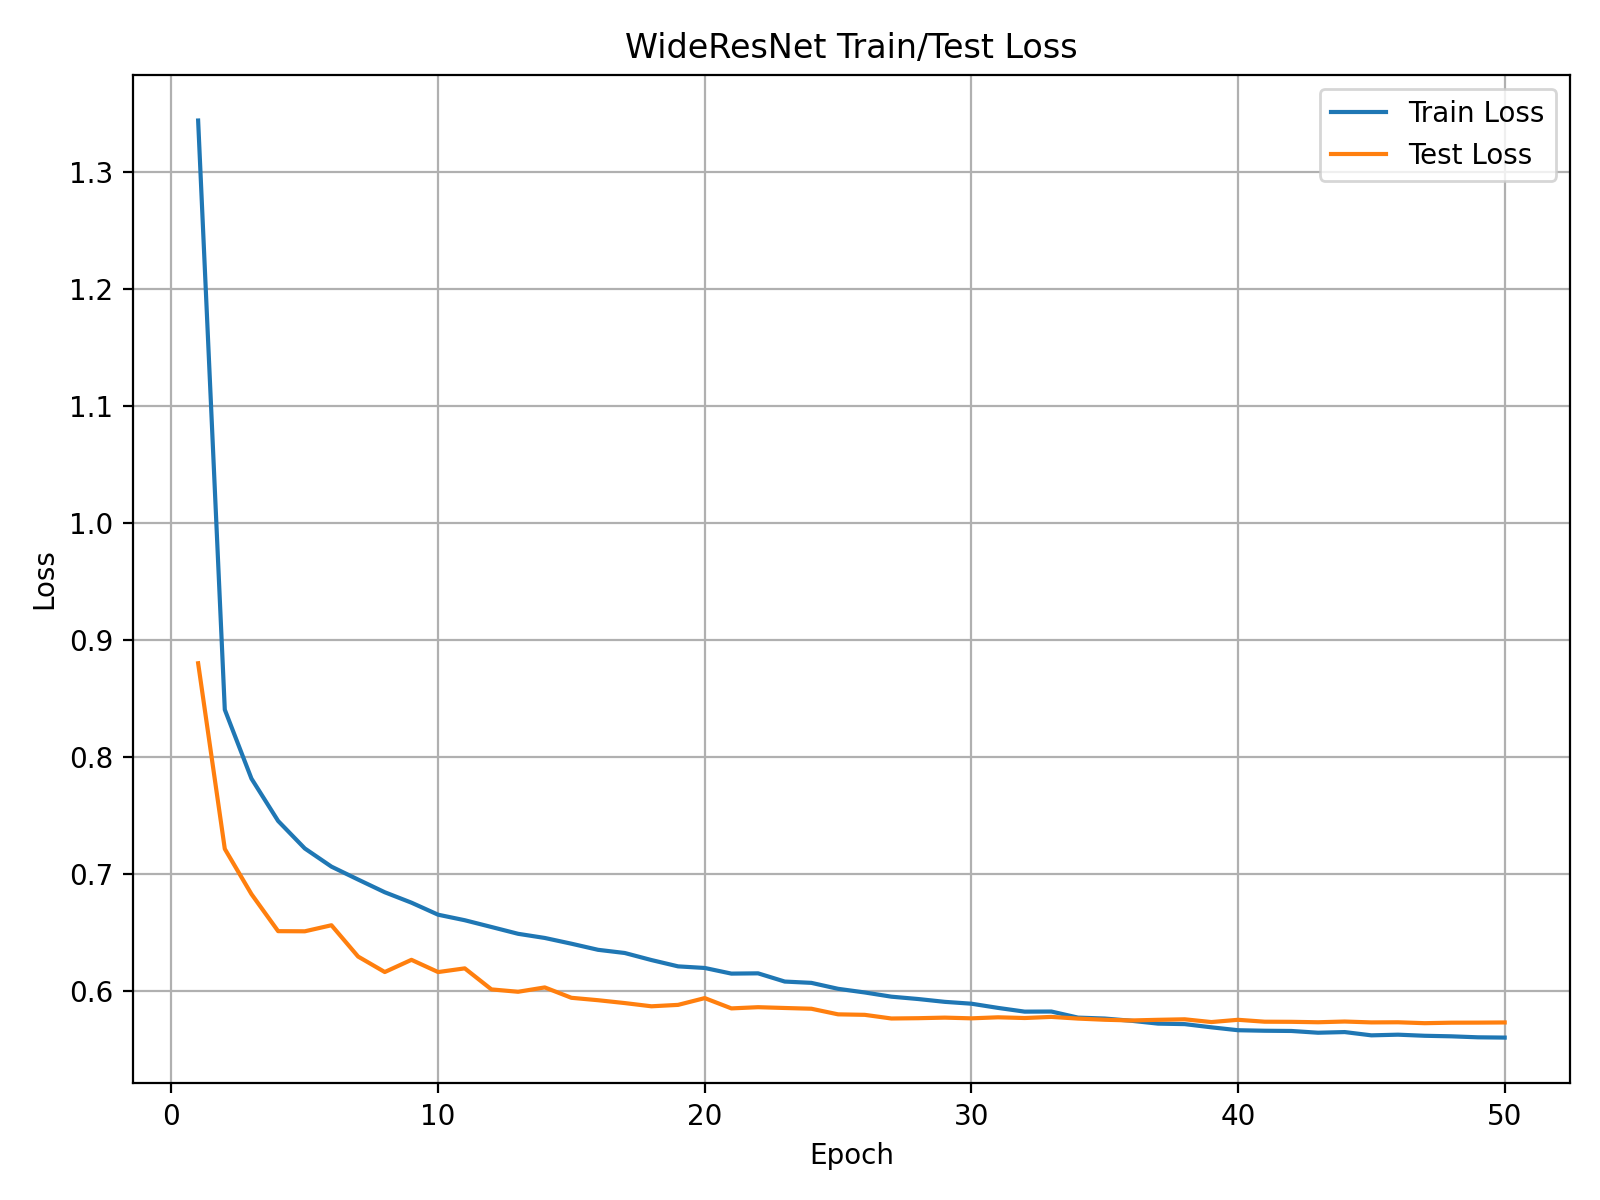

### 4.2 结果分析
（1）从 Baseline CNN 的准确率曲线可以看：
随着训练进行，模型迅速收敛；
- 到第 10 个 epoch 左右，训练准确率已超过 90%；
- 到第 50 个 epoch 时，训练准确率约为 95.5%，测试准确率约为 96.6%；

从损失曲线看：
- 训练损失从约 1.97 持续下降到- 约 0.15；
- 测试损失从约 1.00 下降到约 0.15；

从整体结果来看，Baseline CNN 可以稳定收敛，同时训练集与测试集之间差距较小，没有表现出明显的严重过拟合。对于 SVHN 这种相对规则的 32×32 小尺寸数字图像，合理的基础 CNN 已经能够取得较好的分类效果。

（2）从 ResNet18 的准确率曲线可以看出：

- 到第 20 个 epoch 以后，测试准确率基本稳定在 96.5% 左右；
- 到第 50 个 epoch 时，训练准确率约为 99.5%，而测试准确率约为 96.5%；

从损失曲线看：
- 训练损失从约 0.70 持续下降到接近 0.02;
- 测试损失在前 20 个 epoch 左右下降到最低点，约为 0.14，之后测试损失开始缓慢回升，到第 50 个 epoch 上升到约 0.19；

ResNet18 的训练准确率显著高于 Baseline CNN，说明其拟合能力更强、特征表达能力更好。但从第 20 个 epoch 之后虽然训练准确率继续上升，训练损失继续下降，但是测试准确率基本不再明显提高，测试损失反而逐渐回升，说明 ResNet18 出现了较明显的过拟合趋势。 这可能是因为 ResNet18 模型容量更大，更深的网络虽然具有更强的拟合能力，但在当前任务下可能学习到训练集中的细节噪声，从而导致过拟合。

（3）从 WideResNet 的准确率曲线可以看出：

- 第 2～5 个 epoch 内模型快速收敛，测试准确率很快提升至 94% 左右；
- 到第 50 个 epoch 时，训练准确率约为 97.8%，测试准确率约为 97.4%；

从损失曲线看：

- 训练损失从约 1.34 持续下降到约 0.56，测试损失从约 0.88 下降到约 0.57；
- 训练损失与测试损失在后期逐渐接近，并且整体波动较小，没有出现过拟合现象；

WideResNet 在本实验中表现出了更优的准确率、较好的泛化能力和更稳定的优化过程。相比单纯加深网络层数，WideResNet 通过增加网络宽度增强特征表达能力，可能更适合 CIFAR、SVHN 这类 32×32 小图像任务。习到训练集中的细节噪声，从而导致过拟合。

## 5 总结

首先，实验结果表明，CNN 基础模型已经能够在 SVHN 任务上取得较好的分类效果，说明对于 32×32 的数字图像分类任务，基础卷积神经网络已经具有较强的特征提取和判别能力。ResNet18 的结果体现了残差结构在深层网络优化中的优势。与 Baseline CNN 相比，ResNet18 在训练初期收敛更快，训练集精度更高，说明残差连接确实有助于深层网络的训练。然而，从实验曲线可以看出，ResNet18 在训练后期出现了明显的过拟合趋势：训练损失持续下降，训练准确率接近饱和，但测试损失有所回升，测试准确率提升有限。这说明在 SVHN 这样的小尺寸图像任务中，单纯增加网络深度并不一定能够持续带来更好的泛化性能。
WideResNet 在本实验中取得了最优的综合结果。通过增加网络宽度来提升模型的特征表达能力。实验结果表明，WideResNet 不仅取得了最高的测试准确率，而且训练曲线和测试曲线更加平稳，测试损失在后期也没有出现明显恶化。这说明对于 SVHN 这类 32×32 小图像分类任务，适度增加网络宽度比单纯加深网络更有效，能够在拟合能力和泛化能力之间取得更好的平衡。

通过本次实验，我进一步理解了卷积神经网络在图像分类任务中的基本流程，包括数据预处理、模型设计、训练优化和结果分析。和结果分析。参考意义。